In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
try:
    from IPython.display import display
except ImportError:
    display = print

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/interaction_type_bout.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/interaction_type_bout.csv')
df2['Condition'] = 'Fed-Starved'

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/interaction_type_bout.csv')
df3['Condition'] = 'Starved-Starved'

all_bouts = pd.concat([df1, df2, df3], ignore_index=True)

order = ['Fed-Fed', 'Fed-Starved', 'Starved-Starved']
palette = {
    "Fed-Fed": "#4C72B0",
    "Fed-Starved": "#55A868",
    "Starved-Starved": "#C44E52",
}

interaction_type = 'head_head'

available_initial_types = sorted(all_bouts['initial_type'].dropna().unique())
if interaction_type not in available_initial_types:
    raise ValueError(
        f"interaction_type must be one of {available_initial_types}; got {interaction_type!r}"
    )

df = all_bouts.loc[all_bouts['initial_type'] == interaction_type].copy()
df['interaction_number'] = df.groupby(['Condition', 'file']).cumcount() + 1

print(f"Keeping initial_type == {interaction_type!r}")
display(
    all_bouts.groupby(['Condition', 'initial_type'])
      .size()
      .rename('n_bouts')
      .reset_index()
)

Keeping initial_type == 'head_head'


,Condition,initial_type,n_bouts
0,Fed-Fed,body_head,15
1,Fed-Fed,head_head,44
2,Fed-Fed,head_tail,33
3,Fed-Starved,body_head,5
4,Fed-Starved,head_head,20
5,Fed-Starved,head_tail,16
6,Starved-Starved,body_head,12
7,Starved-Starved,head_head,25
8,Starved-Starved,head_tail,18


,count,mean,std,min,25%,50%,75%,max
Condition,,,,,,,,
Fed-Fed,21.0,2.095238,1.841325,0.0,1.00,2.0,3.0,8.0
Fed-Starved,14.0,1.428571,1.283881,0.0,0.25,1.0,2.0,4.0
Starved-Starved,16.0,1.562500,1.412740,0.0,0.75,1.0,3.0,4.0


,Comparison,n 1,n 2,Mann-Whitney U,p value,sig
0,Fed-Fed vs Fed-Starved,21,14,178.0,0.293100,
1,Fed-Starved vs Starved-Starved,14,16,107.5,0.863612,


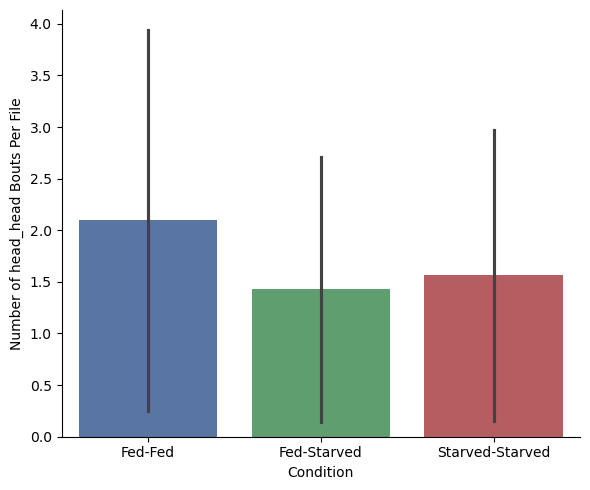

In [2]:
file_index = all_bouts[['Condition', 'file']].drop_duplicates()

bout_counts = (
    file_index.merge(
        df.groupby(['Condition', 'file'], as_index=False)
          .size()
          .rename(columns={'size': 'n_bouts'}),
        on=['Condition', 'file'],
        how='left',
    )
    .fillna({'n_bouts': 0})
)
bout_counts['n_bouts'] = bout_counts['n_bouts'].astype(int)

display(bout_counts.groupby('Condition')['n_bouts'].describe())

count_results = []
for group_1, group_2 in [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]:
    values_1 = bout_counts.loc[bout_counts['Condition'] == group_1, 'n_bouts']
    values_2 = bout_counts.loc[bout_counts['Condition'] == group_2, 'n_bouts']
    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')
    count_results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'n 1': len(values_1),
        'n 2': len(values_2),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': '*' if p_value < 0.05 else '',
    })

count_mann_whitney_results = pd.DataFrame(count_results)
display(count_mann_whitney_results)

plt.figure(figsize=(6,5))

sns.barplot(
    data=bout_counts,
    x='Condition',
    y='n_bouts',
    hue='Condition',
    order=order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
    legend=False,
)

plt.ylim(0, None)
plt.ylabel(f'Number of {interaction_type} Bouts Per File')
plt.xlabel('Condition')
sns.despine()
plt.tight_layout()
plt.show()

,count,mean,std,min,25%,50%,75%,max
Condition,,,,,,,,
Fed-Fed,17.0,3.884804,2.103936,1.0,2.125,3.5,5.0000,7.0
Fed-Starved,10.0,2.691667,1.638677,1.0,1.375,2.5,3.4375,6.0
Starved-Starved,12.0,6.118056,4.507353,1.0,3.500,5.5,7.3750,18.0


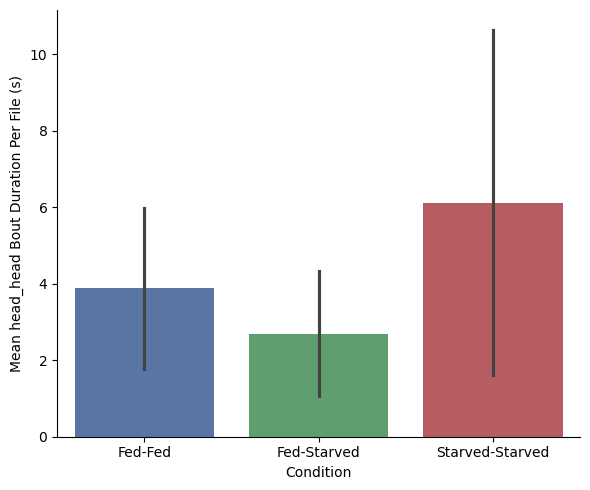

In [3]:
duration_per_file = (
    df.groupby(['Condition', 'file'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

display(duration_per_file.groupby('Condition')['mean_bout_duration'].describe())

plt.figure(figsize=(6,5))

sns.barplot(
    data=duration_per_file,
    x='Condition',
    y='mean_bout_duration',
    hue='Condition',
    order=order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
    legend=False,
)

plt.ylim(0, None)
plt.ylabel(f'Mean {interaction_type} Bout Duration Per File (s)')
plt.xlabel('Condition')
sns.despine()
plt.tight_layout()
plt.show()

In [4]:
from scipy.stats import mannwhitneyu

duration_comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
    ('Fed-Fed', 'Starved-Starved'),
]

duration_results = []

for group_1, group_2 in duration_comparisons:
    values_1 = duration_per_file.loc[
        duration_per_file['Condition'] == group_1,
        'mean_bout_duration'
    ]
    values_2 = duration_per_file.loc[
        duration_per_file['Condition'] == group_2,
        'mean_bout_duration'
    ]

    stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

    duration_results.append({
        'Comparison': f'{group_1} vs {group_2}',
        'Mann-Whitney U': stat,
        'p value': p_value,
    })

duration_mann_whitney_results = pd.DataFrame(duration_results)
duration_mann_whitney_results


,Comparison,Mann-Whitney U,p value
0,Fed-Fed vs Fed-Starved,117.0,0.112747
1,Fed-Starved vs Starved-Starved,25.0,0.022607
2,Fed-Fed vs Starved-Starved,71.0,0.175768


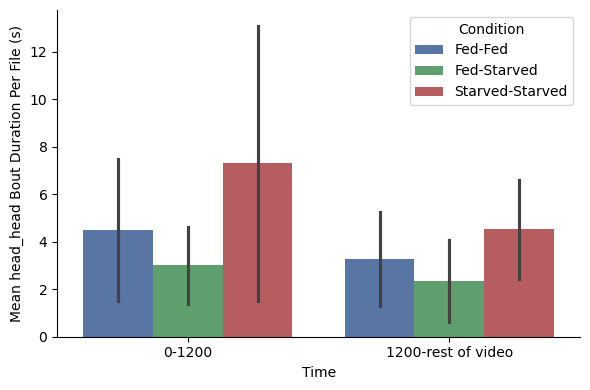

In [5]:
df['time_bin'] = np.where(
    df['start_frame'] < 1200,
    '0-1200',
    '1200-rest of video',
)

time_bin_order = ['0-1200', '1200-rest of video']

duration_0_1200_rest_hue = (
    df.groupby(['Condition', 'file', 'time_bin'], as_index=False)['duration']
      .mean()
      .rename(columns={'duration': 'mean_bout_duration'})
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=duration_0_1200_rest_hue,
    x='time_bin',
    y='mean_bout_duration',
    hue='Condition',
    order=time_bin_order,
    hue_order=order,
    palette=palette,
    errorbar='sd',
)

plt.xlabel('Time')
plt.ylabel(f'Mean {interaction_type} Bout Duration Per File (s)')
plt.ylim(0, None)
sns.despine()
plt.tight_layout()
# plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/mean-head-duration-0-1200-1200-end.pdf', format='pdf')
plt.show()

In [6]:
# Simple Mann-Whitney tests for the plot above.
from scipy.stats import mannwhitneyu

results = []

def add_mann_whitney(test_type, group, comparison, values_1, values_2):
    values_1 = values_1.dropna()
    values_2 = values_2.dropna()

    if len(values_1) == 0 or len(values_2) == 0:
        stat = np.nan
        p_value = np.nan
    else:
        stat, p_value = mannwhitneyu(values_1, values_2, alternative='two-sided')

    results.append({
        'Test Type': test_type,
        'Group': group,
        'Comparison': comparison,
        'n 1': len(values_1),
        'n 2': len(values_2),
        'Mann-Whitney U': stat,
        'p value': p_value,
        'sig': '*' if pd.notna(p_value) and p_value < 0.05 else '',
    })

# Within each condition: 0-1200 vs rest of video.
for condition in order:
    condition_data = duration_0_1200_rest_hue[
        duration_0_1200_rest_hue['Condition'] == condition
    ]

    values_0_1200 = condition_data.loc[
        condition_data['time_bin'] == '0-1200',
        'mean_bout_duration'
    ]
    values_rest = condition_data.loc[
        condition_data['time_bin'] == '1200-rest of video',
        'mean_bout_duration'
    ]

    add_mann_whitney(
        'Within condition',
        condition,
        '0-1200 vs 1200-rest of video',
        values_0_1200,
        values_rest,
    )

# Within each time bin: compare conditions.
comparisons = [
    ('Fed-Fed', 'Fed-Starved'),
    ('Fed-Starved', 'Starved-Starved'),
]

for time_bin in time_bin_order:
    time_data = duration_0_1200_rest_hue[
        duration_0_1200_rest_hue['time_bin'] == time_bin
    ]

    for group_1, group_2 in comparisons:
        values_1 = time_data.loc[
            time_data['Condition'] == group_1,
            'mean_bout_duration'
        ]
        values_2 = time_data.loc[
            time_data['Condition'] == group_2,
            'mean_bout_duration'
        ]

        add_mann_whitney(
            'Within time bin',
            time_bin,
            f'{group_1} vs {group_2}',
            values_1,
            values_2,
        )

mann_whitney_0_1200_rest_results = pd.DataFrame(results)
mann_whitney_0_1200_rest_results

,Test Type,Group,Comparison,n 1,n 2,Mann-Whitney U,p value,sig
0,Within condition,Fed-Fed,0-1200 vs 1200-rest of video,9,15,84.0,0.337310,
1,Within condition,Fed-Starved,0-1200 vs 1200-rest of video,7,6,28.5,0.310570,
2,Within condition,Starved-Starved,0-1200 vs 1200-rest of video,9,7,39.0,0.456726,
3,Within time bin,0-1200,Fed-Fed vs Fed-Starved,9,7,40.5,0.363635,
4,Within time bin,0-1200,Fed-Starved vs Starved-Starved,7,9,17.0,0.135162,
5,Within time bin,1200-rest of video,Fed-Fed vs Fed-Starved,15,6,59.0,0.290275,
6,Within time bin,1200-rest of video,Fed-Starved vs Starved-Starved,6,7,8.0,0.071763,
